# **Laboratorio 7 - Visión por Computadora**

- Paula Barillas - 22764
- Gerardo Pineda - 22880
- Mónica Salvatierra - 22249

Link del repositorio: https://github.com/alee2602/LAB7-VCP

---

## **Task 3**
---

### **Imports**

In [60]:
import os
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
from torchvision import models
import torch.nn as nn
import copy
import time
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, recall_score

### **Definir ruta del dataset**

In [2]:
DATASET_DIR = Path("data/chest_xray")  

print(DATASET_DIR.exists())
print(list(DATASET_DIR.iterdir()))

True
[WindowsPath('data/chest_xray/test'), WindowsPath('data/chest_xray/train'), WindowsPath('data/chest_xray/val')]


### **Obtener rutas y etiquetarlas**

In [3]:
def collect_paths(dataset_dir):
    records = []
    splits = ["train", "val", "test"]
    classes = ["NORMAL", "PNEUMONIA"]

    for split in splits:
        for class_name in classes:
            class_dir = dataset_dir / split / class_name
            
            if not class_dir.exists():
                print(f"Advertencia: no existe {class_dir}")
                continue

            for img_path in class_dir.glob("*"):
                if img_path.is_file():
                    records.append({
                        "filepath": str(img_path),
                        "label_name": class_name,
                        "label": 0 if class_name == "NORMAL" else 1,
                        "original_split": split
                    })

    return pd.DataFrame(records)

### **Unificar datatset**

In [4]:
df = collect_paths(DATASET_DIR)

print("Total de imágenes:", len(df))
df.head()

Total de imágenes: 5856


,filepath,label_name,label,original_split
0,data\chest_xray\train\NORMAL\IM-0115-0001.jpeg,NORMAL,0,train
1,data\chest_xray\train\NORMAL\IM-0117-0001.jpeg,NORMAL,0,train
2,data\chest_xray\train\NORMAL\IM-0119-0001.jpeg,NORMAL,0,train
3,data\chest_xray\train\NORMAL\IM-0122-0001.jpeg,NORMAL,0,train
4,data\chest_xray\train\NORMAL\IM-0125-0001.jpeg,NORMAL,0,train


### **Obtener distribución general**

In [5]:
print(df["label_name"].value_counts())
print()
print(df["label_name"].value_counts(normalize=True))

label_name
PNEUMONIA    4273
NORMAL       1583
Name: count, dtype: int64

label_name
PNEUMONIA    0.729679
NORMAL       0.270321
Name: proportion, dtype: float64


Observaciones: Las clases se encuentran desbalanceadas, puesto que existen más imágenes de pulmones con pneumonía bacteriana que sin

### **Realizar split estratificado**

In [6]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Tamaño total:", len(df))
print("Train:", len(train_df), f"({len(train_df)/len(df):.2%})")
print("Val:", len(val_df), f"({len(val_df)/len(df):.2%})")
print("Test:", len(test_df), f"({len(test_df)/len(df):.2%})")

Tamaño total: 5856
Train: 4099 (70.00%)
Val: 878 (14.99%)
Test: 879 (15.01%)


In [8]:
def show_distribution(name, subset_df):
    print(f"--- {name} ---")
    print(subset_df["label_name"].value_counts())
    print()
    print(subset_df["label_name"].value_counts(normalize=True))
    print()

show_distribution("TRAIN", train_df)
show_distribution("VALIDATION", val_df)
show_distribution("TEST", test_df)

--- TRAIN ---
label_name
PNEUMONIA    2991
NORMAL       1108
Name: count, dtype: int64

label_name
PNEUMONIA    0.72969
NORMAL       0.27031
Name: proportion, dtype: float64

--- VALIDATION ---
label_name
PNEUMONIA    641
NORMAL       237
Name: count, dtype: int64

label_name
PNEUMONIA    0.730068
NORMAL       0.269932
Name: proportion, dtype: float64

--- TEST ---
label_name
PNEUMONIA    641
NORMAL       238
Name: count, dtype: int64

label_name
PNEUMONIA    0.729238
NORMAL       0.270762
Name: proportion, dtype: float64



### **Resetear índices**

In [7]:
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [8]:
train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)

print("Splits guardados en CSV.")

Splits guardados en CSV.


In [9]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0

### **Data Augmentation**

In [16]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(degrees=5),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.02, 0.02),
        scale=(0.98, 1.02)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### **Datatset personalizado**

In [17]:
class ChestXRayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = row["filepath"]
        label = int(row["label"])

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [18]:
train_dataset = ChestXRayDataset(train_df, transform=train_transform)
val_dataset = ChestXRayDataset(val_df, transform=eval_transform)
test_dataset = ChestXRayDataset(test_df, transform=eval_transform)

### **Crear dataloaders**

In [19]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

In [20]:
images, labels = next(iter(train_loader))

print("Batch de imágenes:", images.shape)
print("Batch de labels:", labels.shape)
print("Labels ejemplo:", labels[:10])

Batch de imágenes: torch.Size([32, 3, 224, 224])
Batch de labels: torch.Size([32])
Labels ejemplo: tensor([1, 1, 1, 0, 1, 0, 1, 1, 1, 1])


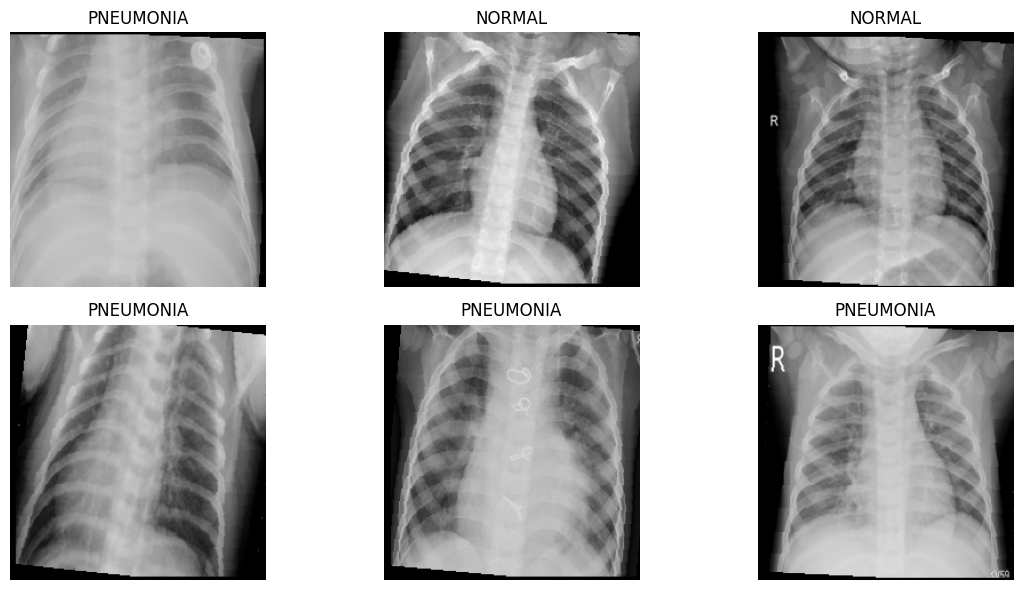

In [ ]:

def imshow_tensor(img_tensor):
    img = img_tensor.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis("off")

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    imshow_tensor(images[i])
    plt.title("PNEUMONIA" if labels[i].item() == 1 else "NORMAL")
plt.tight_layout()
plt.show()

In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

Usando dispositivo: cuda


### **Congelar capas y entrenamiento de modelos**

In [22]:
def freeze_model_base(model):
    for param in model.parameters():
        param.requires_grad = False

In [25]:
mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

# congelar toda la base
freeze_model_base(mobilenet)

# reemplazar clasificador final
in_features_mobilenet = mobilenet.classifier[1].in_features

mobilenet.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(in_features_mobilenet, 2)
)

mobilenet = mobilenet.to(device)
print(mobilenet)

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [26]:
densenet = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

# congelar toda la base
freeze_model_base(densenet)

# reemplazar clasificador final
in_features_densenet = densenet.classifier.in_features
densenet.classifier = nn.Linear(in_features_densenet, 2)

densenet = densenet.to(device)
print(densenet)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\ALEJANDRA/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth


100.0%


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [27]:
def count_trainable_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total_m, trainable_m = count_trainable_parameters(mobilenet)
total_d, trainable_d = count_trainable_parameters(densenet)

print("MobileNetV2")
print("Total parámetros:", total_m)
print("Entrenables:", trainable_m)
print()

print("DenseNet121")
print("Total parámetros:", total_d)
print("Entrenables:", trainable_d)

MobileNetV2
Total parámetros: 2226434
Entrenables: 2562

DenseNet121
Total parámetros: 6955906
Entrenables: 2050


### **Evaluación de los modelos**

In [29]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, pos_label=1)
    epoch_recall = recall_score(all_labels, all_preds, pos_label=1)

    return {
        "loss": epoch_loss,
        "accuracy": epoch_acc,
        "f1": epoch_f1,
        "recall": epoch_recall
    }

### **Training loop**

In [30]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs=15,
    patience=3,
    model_name="model"
):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": [],
        "val_recall": []
    }

    best_val_loss = float("inf")
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_without_improvement = 0

    start_time = time.time()

    for epoch in range(num_epochs):
        model.train()

        running_loss = 0.0
        all_train_labels = []
        all_train_preds = []

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_train_labels.extend(labels.cpu().numpy())
            all_train_preds.extend(preds.cpu().numpy())

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = accuracy_score(all_train_labels, all_train_preds)

        val_metrics = evaluate_model(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_recall"].append(val_metrics["recall"])

        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_metrics['loss']:.4f} | Val Acc: {val_metrics['accuracy']:.4f}")
        print(f"Val F1:     {val_metrics['f1']:.4f} | Val Recall: {val_metrics['recall']:.4f}")
        print("-" * 50)

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0

            torch.save(best_model_wts, f"best_{model_name}.pth")
            print(f"Mejor modelo guardado: best_{model_name}.pth")
        else:
            epochs_without_improvement += 1
            print(f"Sin mejora en val_loss por {epochs_without_improvement} época(s).")

        if epochs_without_improvement >= patience:
            print(f"Early stopping activado en la época {epoch+1}.")
            break

    total_time = time.time() - start_time
    print(f"Entrenamiento completado en {total_time/60:.2f} minutos.")

    model.load_state_dict(best_model_wts)

    return model, history

In [31]:
class_counts = train_df["label"].value_counts().sort_index()
class_counts

label
0    1108
1    2991
Name: count, dtype: int64

In [32]:
num_samples = len(train_df)
num_classes = 2

class_weights = num_samples / (num_classes * class_counts)
class_weights = torch.tensor(class_weights.values, dtype=torch.float32).to(device)

print("Class weights:", class_weights)

Class weights: tensor([1.8497, 0.6852], device='cuda:0')


In [35]:
criterion_mobilenet = nn.CrossEntropyLoss(weight=class_weights)

optimizer_mobilenet = torch.optim.Adam(
    mobilenet.parameters(),
    lr=1e-3
)

mobilenet, history_mobilenet = train_model(
    model=mobilenet,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_mobilenet,
    optimizer=optimizer_mobilenet,
    device=device,
    num_epochs=15,
    patience=3,
    model_name="mobilenetv2"
)


Epoch [1/15]
Train Loss: 0.2864 | Train Acc: 0.8939
Val Loss:   0.2645 | Val Acc: 0.8599
Val F1:     0.8950 | Val Recall: 0.8175
--------------------------------------------------
Mejor modelo guardado: best_mobilenetv2.pth
Epoch [2/15]
Train Loss: 0.2428 | Train Acc: 0.9088
Val Loss:   0.2284 | Val Acc: 0.8918
Val F1:     0.9210 | Val Recall: 0.8643
--------------------------------------------------
Mejor modelo guardado: best_mobilenetv2.pth
Epoch [3/15]
Train Loss: 0.2166 | Train Acc: 0.9127
Val Loss:   0.2001 | Val Acc: 0.9043
Val F1:     0.9309 | Val Recall: 0.8830
--------------------------------------------------
Mejor modelo guardado: best_mobilenetv2.pth
Epoch [4/15]
Train Loss: 0.2073 | Train Acc: 0.9175
Val Loss:   0.2004 | Val Acc: 0.9009
Val F1:     0.9278 | Val Recall: 0.8721
--------------------------------------------------
Sin mejora en val_loss por 1 época(s).
Epoch [5/15]
Train Loss: 0.2035 | Train Acc: 0.9207
Val Loss:   0.1800 | Val Acc: 0.9248
Val F1:     0.9465 |

In [36]:
criterion_densenet = nn.CrossEntropyLoss(weight=class_weights)

optimizer_densenet = torch.optim.Adam(
    densenet.parameters(),
    lr=1e-3
)

densenet, history_densenet = train_model(
    model=densenet,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_densenet,
    optimizer=optimizer_densenet,
    device=device,
    num_epochs=15,
    patience=3,
    model_name="densenet121"
) 

Epoch [1/15]
Train Loss: 0.3740 | Train Acc: 0.8607
Val Loss:   0.2797 | Val Acc: 0.8565
Val F1:     0.8919 | Val Recall: 0.8112
--------------------------------------------------
Mejor modelo guardado: best_densenet121.pth
Epoch [2/15]
Train Loss: 0.2426 | Train Acc: 0.9149
Val Loss:   0.2087 | Val Acc: 0.9146
Val F1:     0.9395 | Val Recall: 0.9080
--------------------------------------------------
Mejor modelo guardado: best_densenet121.pth
Epoch [3/15]
Train Loss: 0.2132 | Train Acc: 0.9195
Val Loss:   0.2052 | Val Acc: 0.9021
Val F1:     0.9289 | Val Recall: 0.8768
--------------------------------------------------
Mejor modelo guardado: best_densenet121.pth
Epoch [4/15]
Train Loss: 0.1974 | Train Acc: 0.9249
Val Loss:   0.1971 | Val Acc: 0.9055
Val F1:     0.9315 | Val Recall: 0.8799
--------------------------------------------------
Mejor modelo guardado: best_densenet121.pth
Epoch [5/15]
Train Loss: 0.1891 | Train Acc: 0.9283
Val Loss:   0.1769 | Val Acc: 0.9317
Val F1:     0.9

### **Historial de entrenamiento**

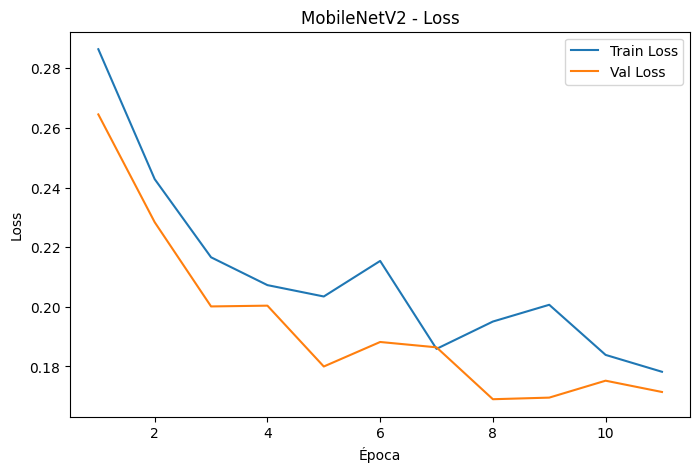

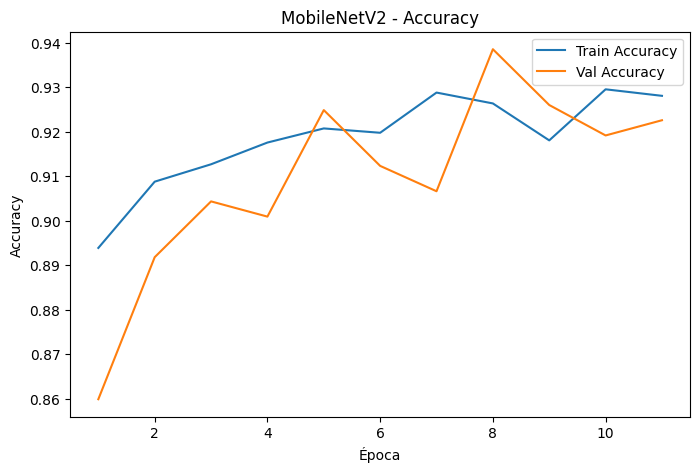

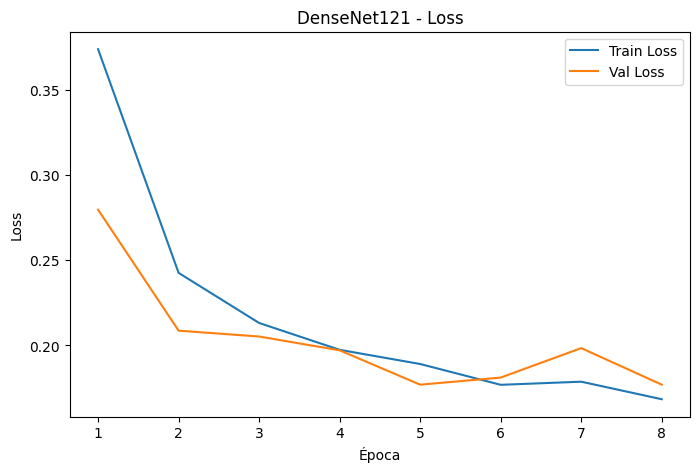

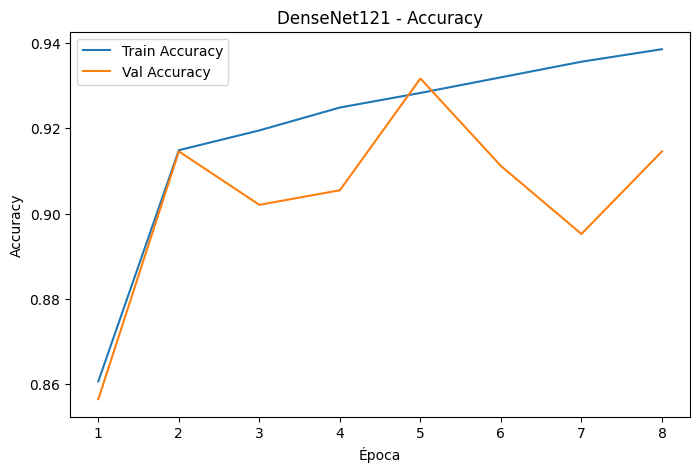

In [ ]:
def plot_history(history, model_name):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.title(f"{model_name} - Loss")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Val Accuracy")
    plt.title(f"{model_name} - Accuracy")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_history(history_mobilenet, "MobileNetV2")
plot_history(history_densenet, "DenseNet121")

In [40]:
def test_model(model, dataloader, device):
    model.eval()

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    f1_pneumonia = f1_score(all_labels, all_preds, pos_label=1)
    recall_pneumonia = recall_score(all_labels, all_preds, pos_label=1)

    return {
        "accuracy": accuracy,
        "f1_pneumonia": f1_pneumonia,
        "recall_pneumonia": recall_pneumonia
    }

In [41]:
mobilenet_test_metrics = test_model(mobilenet, test_loader, device)
densenet_test_metrics = test_model(densenet, test_loader, device)

print("=== MobileNetV2 - Test ===")
for k, v in mobilenet_test_metrics.items():
    print(f"{k}: {v:.4f}")

print("\n=== DenseNet121 - Test ===")
for k, v in densenet_test_metrics.items():
    print(f"{k}: {v:.4f}")

=== MobileNetV2 - Test ===
accuracy: 0.9158
f1_pneumonia: 0.9410
recall_pneumonia: 0.9204

=== DenseNet121 - Test ===
accuracy: 0.9261
f1_pneumonia: 0.9481
recall_pneumonia: 0.9267


In [42]:
def get_model_size_mb(model_path):
    size_bytes = os.path.getsize(model_path)
    size_mb = size_bytes / (1024 * 1024)
    return size_mb

In [43]:
mobilenet_size_mb = get_model_size_mb("best_mobilenetv2.pth")
densenet_size_mb = get_model_size_mb("best_densenet121.pth")

print(f"MobileNetV2 size: {mobilenet_size_mb:.2f} MB")
print(f"DenseNet121 size: {densenet_size_mb:.2f} MB")

MobileNetV2 size: 8.73 MB
DenseNet121 size: 27.12 MB


In [54]:
def measure_inference_time(model, dataset, device, num_images=100):
    model.eval()

    num_images = min(num_images, len(dataset))
    times = []

    with torch.no_grad():
        for i in range(num_images):
            image, _ = dataset[i]
            image = image.unsqueeze(0).to(device)

            if device.type == "cuda":
                torch.cuda.synchronize()

            start_time = time.perf_counter()
            _ = model(image)

            if device.type == "cuda":
                torch.cuda.synchronize()

            end_time = time.perf_counter()

            elapsed_ms = (end_time - start_time) * 1000
            times.append(elapsed_ms)

    return np.mean(times)

In [55]:
mobilenet_inference_ms = measure_inference_time(mobilenet, test_dataset, device, num_images=100)
densenet_inference_ms = measure_inference_time(densenet, test_dataset, device, num_images=100)

print(f"MobileNetV2 avg inference time (100 images): {mobilenet_inference_ms:.2f} ms/image")
print(f"DenseNet121 avg inference time (100 images): {densenet_inference_ms:.2f} ms/image")

MobileNetV2 avg inference time (100 images): 8.37 ms/image
DenseNet121 avg inference time (100 images): 26.69 ms/image


In [56]:
results_df = pd.DataFrame([
    {
        "Model": "MobileNetV2",
        "Accuracy": mobilenet_test_metrics["accuracy"],
        "F1_Pneumonia": mobilenet_test_metrics["f1_pneumonia"],
        "Recall_Pneumonia": mobilenet_test_metrics["recall_pneumonia"],
        "Size_MB": mobilenet_size_mb,
        "Inference_ms_per_image": mobilenet_inference_ms
    },
    {
        "Model": "DenseNet121",
        "Accuracy": densenet_test_metrics["accuracy"],
        "F1_Pneumonia": densenet_test_metrics["f1_pneumonia"],
        "Recall_Pneumonia": densenet_test_metrics["recall_pneumonia"],
        "Size_MB": densenet_size_mb,
        "Inference_ms_per_image": densenet_inference_ms
    }
])

In [57]:
results_df_rounded = results_df.copy()
results_df_rounded["Accuracy"] = results_df_rounded["Accuracy"].round(4)
results_df_rounded["F1_Pneumonia"] = results_df_rounded["F1_Pneumonia"].round(4)
results_df_rounded["Recall_Pneumonia"] = results_df_rounded["Recall_Pneumonia"].round(4)
results_df_rounded["Size_MB"] = results_df_rounded["Size_MB"].round(2)
results_df_rounded["Inference_ms_per_image"] = results_df_rounded["Inference_ms_per_image"].round(2)

results_df_rounded

,Model,Accuracy,F1_Pneumonia,Recall_Pneumonia,Size_MB,Inference_ms_per_image
0,MobileNetV2,0.9158,0.9410,0.9204,8.73,8.37
1,DenseNet121,0.9261,0.9481,0.9267,27.12,26.69


In [58]:
results_df_rounded["F1_percent"] = results_df["F1_Pneumonia"] * 100
results_df_rounded["MB_per_F1_point"] = results_df["Size_MB"] / (results_df["F1_Pneumonia"] * 100)

results_df_rounded[["Model", "Size_MB", "F1_percent", "MB_per_F1_point"]]

,Model,Size_MB,F1_percent,MB_per_F1_point
0,MobileNetV2,8.73,94.098884,0.092767
1,DenseNet121,27.12,94.812450,0.286017


In [59]:
results_df_rounded["Images_per_second"] = 1000 / results_df["Inference_ms_per_image"]
results_df_rounded["Images_per_hour"] = results_df_rounded["Images_per_second"] * 3600

results_df_rounded[["Model", "Inference_ms_per_image", "Images_per_second", "Images_per_hour"]]

,Model,Inference_ms_per_image,Images_per_second,Images_per_hour
0,MobileNetV2,8.37,119.497627,430191.457675
1,DenseNet121,26.69,37.465523,134875.883835


### **Prompt utilizado**

Para la implementación inicial del pipeline, se utilizó un prompt básico de apoyo para estructurar el flujo general del proyecto en PyTorch. El prompt utilizado fue:

*"How can I build a basic image classification pipeline in PyTorch including dataset loading, train/validation split, data augmentation, and model training?"*

Este prompt permitió obtener un esqueleto general del proceso, incluyendo la organización del código en etapas (carga de datos, transformaciones, modelo y entrenamiento). Sin embargo, la solución final no se basó directamente en la salida generada, sino que fue adaptada y refinada manualmente. SEn particular, se realizaron decisiones específicas del problema, como la unificación del dataset original, la implementación de una división estratificada 70/15/15, el diseño de un pipeline de data augmentation adecuado para imágenes médicas y la selección y modificación de modelos preentrenados. 